##### Importing libraries

In [ ]:
from collections import Counter
import re
import os

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



##### Mapping the positive and negative as such:

| Event | N (Participants) | Context for Lying | Motivation Category |
| :--- | :--- | :--- | :--- |
| A job interview for your dream job | 160 | Inflate your past experiences to get the job | Positive Gain |
| Being hospitalized and undergoing surgery | 70 | Exaggerate some side effects to receive extra compensation | Positive Gain |
| Being involved in a car accident | 47 | Increase the claimed amount of damage you received to get more money | Positive Gain |
| **Total Positive Gain** | **277** | | |
| Causing a car accident | 15 | Describe the event so that it's not your fault | Negative Gain |
| Cheating on an exam | 48 | Describing how you passed the exam, given that you cannot admit that you cheated | Negative Gain |
| Getting a speeding fine | 62 | Pretend it wasn't you driving the car that day | Negative Gain |
| Getting fired | 34 | Pretend that you just had a bad day at work | Negative Gain |
| Missing a deadline at work | 97 | Find excuses that allow you not to appear forgetful or disorganised | Negative Gain |
| Taking the bus/train without the ticket | 124 | Convince the ticket inspector that they shouldn't fine you for not having the ticket | Negative Gain |
| **Total Negative Gain** | **380** | | |

In [ ]:
# Loading data
df = pd.read_csv("C:/Users/20193623/OneDrive - TU Eindhoven/BEP/Mijn project/Code/Mijn code/Data/1_Embedded_lies_dataset/Embedded_lies_manprep.csv", sep=';')
# Set output directory
output_dir = "C:/Users/20193623/OneDrive - TU Eindhoven/BEP/Mijn project/Code/Mijn code/Data/"

# Drop romantic scenarios and 'None of them'
romantic_scenarios_to_drop = [
    'Ending a long romantic relationship',
    'Cheating on your partner'
]

df_filtered = df[df['Event'] != 'None of them'].copy()
df_filtered = df_filtered[~df_filtered['Event'].isin(romantic_scenarios_to_drop)].copy()

print("Originele DataFrame shape:", df.shape)
print("Gefilterde DataFrame shape:", df_filtered.shape)

# Binary classificatie kolom toevoegen
positive_gain_events = [
    'A job interview for your dream job',
    'Being hospitalised and undergoing surgery',
    'Being involved in a car accident'
]
df_filtered['is_positive_gain'] = df_filtered['Event'].isin(positive_gain_events).astype(int)

# Sorteer de dataframe op basis van 'is_positive_gain'
df_filtered.sort_values(by='is_positive_gain', ascending=False, inplace=True)

# Herindexeren van de gefilterde DataFrame
df_filtered.reset_index(drop=True, inplace=True)

print("\nDataFrame met nieuwe binaire kolom:")
print(df_filtered[['Event', 'is_positive_gain']].head())
print("\nWaarden telling voor de nieuwe kolom:")
print(df_filtered['is_positive_gain'].value_counts())

df_filtered.to_csv(("C:/Users/20193623/OneDrive - TU Eindhoven/BEP/Mijn project/Code/Mijn code/Data/df_filtered.csv"), index=False)


Originele DataFrame shape: (1042, 131)
Gefilterde DataFrame shape: (657, 131)

DataFrame met nieuwe binaire kolom:
                                       Event  is_positive_gain
0         A job interview for your dream job                 1
1           Being involved in a car accident                 1
2  Being hospitalised and undergoing surgery                 1
3           Being involved in a car accident                 1
4         A job interview for your dream job                 1

Waarden telling voor de nieuwe kolom:
is_positive_gain
0    380
1    277
Name: count, dtype: int64


In [ ]:
def extract_lies(dataframe):
    """"
    Extract individual lies from the specified lie columns in the dataframe.
    """
    lie_columns = [f'Embedded_lies_{i}' for i in range(1, 21)]
    docs = []

    for _, row in dataframe.iterrows():
        for col in lie_columns:
            if col in dataframe.columns:
                lie_text = row[col]
                # Controleer op missende of lege waarden
                if pd.notna(lie_text) and str(lie_text).strip() != '':
                    docs.append(str(lie_text))
    return docs


docs = extract_lies(df_filtered)

print(f"Totaal aantal individuele leugens: {len(docs)}")

Totaal aantal individuele leugens: 3256


### Looking into the amount of lies and their length


Statistieken van Woordenaantal:
- Gemiddelde (Average): 9.38
- Mediaan (Median): 7.0
- Minimum (Min): 1
- Maximum (Max): 120


C:\Users\20193623\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


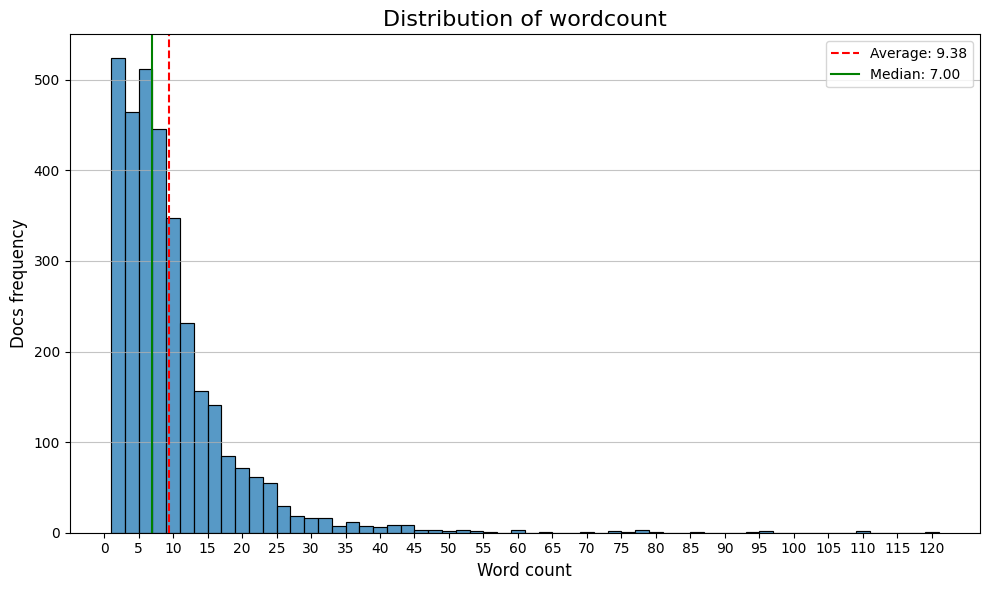

In [ ]:
word_counts = [len(doc.split()) for doc in docs]

# Bereken en print de statistieken
average_words = np.mean(word_counts)
median_words = np.median(word_counts)
min_words = np.min(word_counts)
max_words = np.max(word_counts)

print("\nStatistieken van Woordenaantal:")
print(f"- Gemiddelde (Average): {average_words:.2f}")
print(f"- Mediaan (Median): {median_words}")
print(f"- Minimum (Min): {min_words}")
print(f"- Maximum (Max): {max_words}")

# Maak en sla de plot op
plt.figure(figsize=(10, 6))
sns.histplot(word_counts, bins=range(min_words, max_words + 2, 2))
plt.title('Distribution of wordcount', fontsize=16)
plt.xlabel('Word count', fontsize=12)
plt.ylabel('Docs frequency', fontsize=12)
plt.xticks(np.arange(0, max_words + 5, step=5))
plt.axvline(average_words, color='r', linestyle='--', label=f'Average: {average_words:.2f}')
plt.axvline(median_words, color='g', linestyle='-', label=f'Median: {median_words:.2f}')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig('C:/Users/20193623/OneDrive - TU Eindhoven/BEP/Mijn project/Code/Mijn code/Visualisation/word_count_distribution.png')
plt.show()


##### Drop columns for easy acces and flipping to long df so every row contains a single lie

In [ ]:
keep_cols = [
    "Participant_id",
    "Event",
    "False_event",
    "False_event_num_words",
    "merged_lies",
    "EL_num_words",
    "is_positive_gain"
]
embedded_cols = [c for c in df_filtered.columns if c.startswith("Embedded_lies_") and not any(x in c for x in ["_deceptiveness", "_centrality", "_source"])]
final_cols = keep_cols + embedded_cols

# Maak een 'long format' dataframe
df_long = df_filtered[final_cols].melt(
    id_vars=keep_cols,
    value_vars=embedded_cols,
    var_name="embedded_lie_num",
    value_name="embedded_lie"
)

# Verwijder lege rijen en reset de index
df_long.dropna(subset=["embedded_lie"], inplace=True)
df_long.reset_index(drop=True, inplace=True)
df_long["embedded_lie_num"] = df_long["embedded_lie_num"].str.extract(r"(\d+)").astype(int)
df_long.sort_values(by=["Participant_id", "Event", "embedded_lie_num"], inplace=True)

# Verwijder de "merged_lies" kolom omdat deze niet meer relevant is
df_long.drop(columns='merged_lies', inplace=True)
df_long.reset_index(drop=True, inplace=True)

# Controleer of de embedded lie in de False_event voorkomt
df_long['is_in_false_event'] = df_long.apply(
    lambda row: str(row['embedded_lie']).strip() in str(row['False_event']).strip(), axis=1
)

not_found_count = len(df_long[df_long['is_in_false_event'] == False])
df_long_clean = df_long[df_long['is_in_false_event'] == True].copy()
df_long_clean.drop(columns='is_in_false_event', inplace=True)

print(f"\nAantal rijen in de oorspronkelijke DataFrame: {len(df_long)}")
print(f"Aantal rijen verwijderd (leugen niet gevonden): {not_found_count}")
print(f"Aantal rijen in de opgeschoonde DataFrame: {len(df_long_clean)}")



Aantal rijen in de oorspronkelijke DataFrame: 3256
Aantal rijen verwijderd (leugen niet gevonden): 248
Aantal rijen in de opgeschoonde DataFrame: 3008


##### Function to enrich the short embedded lies with their context from false event

In [ ]:
import re

def enrich_lie_with_control(row, min_words=5, max_words=30, context_window=10):
    """
    Enrich the 'embedded_lie' with context from 'False_event'.
    More robust against punctuation, case, and partial matches.
    Guarantees a minimum word length.
    """
    embedded_lie = str(row['embedded_lie']).strip()
    false_event = str(row['False_event']).strip()

    if not embedded_lie or not false_event:
        return embedded_lie

    # Normalize punctuation and case for matching
    def normalize(text):
        return re.sub(r'[^\w\s]', '', text.lower())

    norm_lie = normalize(embedded_lie)
    norm_event = normalize(false_event)

    lie_words = norm_lie.split()
    event_words = norm_event.split()
    original_word_count = len(lie_words)

    # 1. If already long enough
    if min_words <= original_word_count <= max_words:
        return embedded_lie

    # 2. If too long, truncate
    if original_word_count > max_words:
        return ' '.join(embedded_lie.split()[:max_words])

    # 3. Try to find lie within event (tolerant to minor mismatch)
    lie_start_index = -1
    for i in range(len(event_words) - len(lie_words) + 1):
        window = ' '.join(event_words[i:i + len(lie_words)])
        if window == norm_lie:
            lie_start_index = i
            break
    # fallback: fuzzy token overlap
    if lie_start_index == -1:
        best_overlap = 0
        best_index = -1
        for i in range(len(event_words) - len(lie_words) + 1):
            overlap = len(set(event_words[i:i + len(lie_words)]).intersection(lie_words))
            if overlap > best_overlap:
                best_overlap = overlap
                best_index = i
        if best_overlap > 0:
            lie_start_index = best_index

    # If still not found, just use first min_words from event
    if lie_start_index == -1:
        enriched = ' '.join(false_event.split()[:min(max_words, min_words + context_window)])
        return enriched

    lie_end_index = lie_start_index + len(lie_words)

    # Adjust dynamic window
    left_context = context_window
    right_context = context_window
    if lie_start_index - left_context < 0:
        shift = abs(lie_start_index - left_context)
        left_context = lie_start_index
        right_context = min(right_context + shift, len(event_words) - lie_end_index)
    if lie_end_index + right_context > len(event_words):
        shift = (lie_end_index + right_context) - len(event_words)
        right_context = len(event_words) - lie_end_index
        left_context = max(0, left_context + shift)

    start_slice = max(0, lie_start_index - left_context)
    end_slice = min(len(event_words), lie_end_index + right_context)

    enriched_words = false_event.split()[start_slice:end_slice]

    # Enforce min_words requirement
    if len(enriched_words) < min_words:
        extra_words = false_event.split()[lie_end_index:lie_end_index + (min_words - len(enriched_words))]
        enriched_words += extra_words

    enriched_text = ' '.join(enriched_words[:max_words])
    return enriched_text


In [ ]:

# 2. Analyze word count distribution
df_long_clean['enriched_lie'] = df_long_clean.apply(enrich_lie_with_control, axis=1)

word_counts = df_long_clean['enriched_lie'].str.split().str.len()
average_words = word_counts.mean()
median_words = word_counts.median()
min_words = word_counts.min()
max_words = word_counts.max()

print("\nWord count statistics after enrichment:")
print(f"- Average: {average_words:.2f}")
print(f"- Median: {median_words}")
print(f"- Minimum: {min_words}")



Word count statistics after enrichment:
- Average: 14.87
- Median: 14.0
- Minimum: 5


C:\Users\20193623\AppData\Roaming\Python\Python310\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


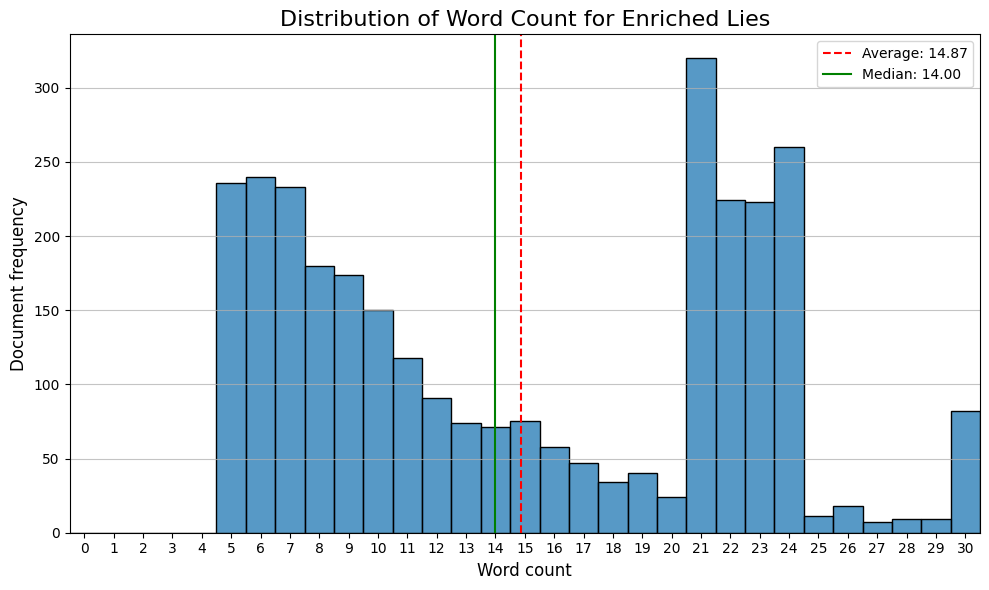

In [ ]:
# 3. Plot distribution
plt.figure(figsize=(10, 6))

# Define bin edges so each bar is centered on integers (0–30)
bins = np.arange(-0.5, 30.5 + 1, 1)

sns.histplot(word_counts, bins=bins, edgecolor='black')

plt.title('Distribution of Word Count for Enriched Lies', fontsize=16)
plt.xlabel('Word count', fontsize=12)
plt.ylabel('Document frequency', fontsize=12)

# Set x-axis ticks from 0 to 30, centered under bars
plt.xticks(np.arange(0, 31, 1))
plt.xlim(-0.5, 30.5)

# Add vertical lines for mean and median
plt.axvline(average_words, color='r', linestyle='--', label=f'Average: {average_words:.2f}')
plt.axvline(median_words, color='g', linestyle='-', label=f'Median: {median_words:.2f}')

plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()

# Save and show the plot
# plt.savefig(
#     r'C:\Users\20193623\OneDrive - TU Eindhoven\BEP\Mijn project\Code\Mijn code\Visualisation\enriched_lie_word_count_distribution.png'
# )
# plt.show()


### You can clearly see that the spike in 21,22,23,24 are the result of the context length so those are basicly all the lies which first were 1,2,3,4 in length because the min value is 5

### plot toevoegen wat de word count van enriched lies vs the embedded lie pakt

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator

# Compute word counts
embedded_counts = df_long_clean['embedded_lie'].str.split().str.len()
enriched_counts = df_long_clean['enriched_lie'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.arange(0, 101, 1)

# Step histograms
sns.histplot(embedded_counts, bins=bins, color='red', element='step', fill=False, linewidth=1.2, ax=ax, label='Embedded Lies')
sns.histplot(enriched_counts, bins=bins, color='green', element='step', fill=False, linewidth=1.2, ax=ax, label='Enriched Lies')

# Inzoomen op het hoofddeel
ax.set_xlim(-0.5, 40)
ax.set_ylim(0, None)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Word count")
ax.set_ylabel("Document frequency")
ax.set_title("Word Count Distribution: Embedded vs Enriched Lies")

# Tail markeren
ax.axvspan(30, enriched_counts.max(), color='gray', alpha=0.15, label='Tail (>30 words)')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()
